# FNO Lab — student version

**Scientific Machine Learning · ENSEEIHT / Toulouse INP**

In this lab, you will build a **Fourier Neural Operator (FNO)** step by step to learn
the operator that maps a forcing term `f(x,y)` to a solution `u(x,y)` for a family of
periodic 2D Poisson equations.

This redesigned version has two goals:
1. make the pedagogical progression explicit;
2. clearly separate what must be **understood**, **completed**, and then **interpreted**.

## Part 0 — Goal of the lab

We consider the family of exact solutions
$$
u_{\alpha,\beta}(x,y) = \cos\bigl(2\pi(\alpha x + \beta y)\bigr),
$$
on the domain $[0,1]^2$ with periodic boundary conditions. The associated forcing is
$$
f_{\alpha,\beta}(x,y) = -\Delta u_{\alpha,\beta}(x,y)
= (2\pi)^2(\alpha^2 + \beta^2)\,u_{\alpha,\beta}(x,y).
$$

Here, we are not trying to solve **one** isolated PDE as in a PINN. We want to learn
the **operator**
$$
f \mapsto u
$$
over a whole family of forcings parameterized by $(\alpha, \beta)$.

**Question 0.** In one or two sentences, explain the difference between:
- learning one specific solution with a PINN;
- learning a family of problems with an FNO.

**Your answer:** *enter your answer here.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Part 1 — Visualizing a few exact solutions

Before building a model, we should inspect the data. We visualize several pairs
$(f_{\alpha,\beta}, u_{\alpha,\beta})$ to understand:
- the spatial structure of the solution;
- the link between spatial frequency and oscillations;
- the fact that the useful information is naturally organized in Fourier modes.

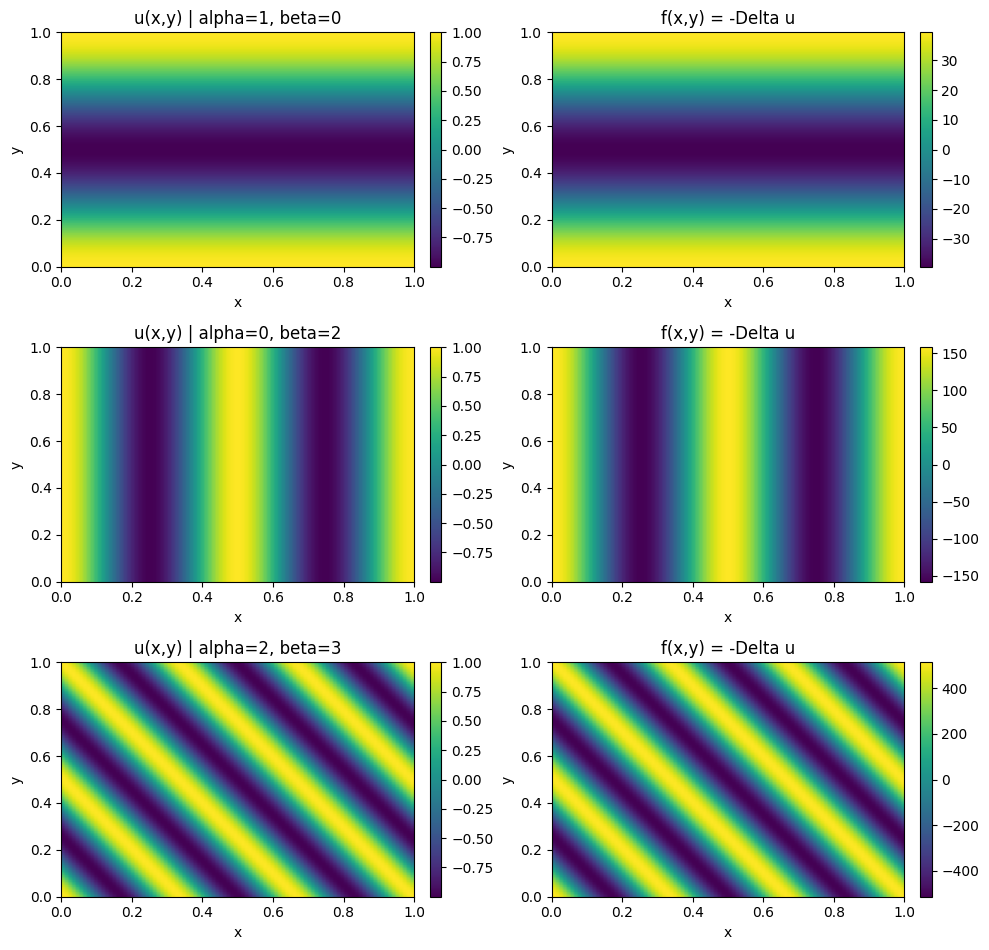

In [2]:
def u_exact_alpha_beta(X, Y, alpha, beta):
    return torch.cos(2.0 * np.pi * (alpha * X + beta * Y))


def f_exact_alpha_beta(X, Y, alpha, beta):
    coeff = (2.0 * np.pi) ** 2 * (alpha ** 2 + beta ** 2)
    return coeff * u_exact_alpha_beta(X, Y, alpha, beta)


def plot_exact_family(pairs, nx=96, ny=96):
    X, Y = torch.meshgrid(
        torch.linspace(0.0, 1.0, nx),
        torch.linspace(0.0, 1.0, ny),
        indexing="ij",
    )

    fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 3.2 * len(pairs)))
    axes = np.atleast_2d(axes)

    for row, (alpha, beta) in enumerate(pairs):
        u = u_exact_alpha_beta(X, Y, alpha, beta)
        f = f_exact_alpha_beta(X, Y, alpha, beta)

        im0 = axes[row, 0].imshow(
            u.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto"
        )
        axes[row, 0].set_title(f"u(x,y) | alpha={alpha}, beta={beta}")
        axes[row, 0].set_xlabel("x")
        axes[row, 0].set_ylabel("y")
        fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

        im1 = axes[row, 1].imshow(
            f.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto"
        )
        axes[row, 1].set_title("f(x,y) = -Delta u")
        axes[row, 1].set_xlabel("x")
        axes[row, 1].set_ylabel("y")
        fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


example_pairs = [(1, 0), (0, 2), (2, 3)]
plot_exact_family(example_pairs)

**Question 1.**
1. What does the pair $(\alpha, \beta)$ control in the solution?
2. Why do we usually exclude the case $(\alpha, \beta) = (0,0)$ in this lab?

**Your answer:** *enter your answer here.*

## Part 2 — Building the dataset

We now want to build a supervised dataset of the form
`[(f_i, u_i)]_{i=1}^N`, with:
- `f_i` and `u_i` viewed as 2D images;
- an explicit channel dimension, hence tensors of shape `(1, Nx, Ny)`;
- a standard train/test split.

To keep the in-class workload reasonable, the sampling of frequencies is already
provided. The coding task here is limited to producing one sample `(f, u)` with the
right tensor shapes.

**Pedagogical objective.** This part is meant to make you work with FNO tensor shapes
before even discussing the architecture.

In [3]:
def make_grid(nx, ny):
    x = torch.linspace(0.0, 1.0, nx, dtype=torch.float32)
    y = torch.linspace(0.0, 1.0, ny, dtype=torch.float32)
    return torch.meshgrid(x, y, indexing="ij")


def sample_frequencies(alpha_values, beta_values, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    alpha_values = np.array(list(alpha_values), dtype=np.int64)
    beta_values = np.array(list(beta_values), dtype=np.int64)

    alpha_data = rng.choice(alpha_values, size=n_samples, replace=True)
    beta_data = rng.choice(beta_values, size=n_samples, replace=True)

    zero_mask = (alpha_data == 0) & (beta_data == 0)
    while np.any(zero_mask):
        alpha_data[zero_mask] = rng.choice(alpha_values, size=zero_mask.sum(), replace=True)
        beta_data[zero_mask] = rng.choice(beta_values, size=zero_mask.sum(), replace=True)
        zero_mask = (alpha_data == 0) & (beta_data == 0)

    return (
        torch.as_tensor(alpha_data, dtype=torch.long),
        torch.as_tensor(beta_data, dtype=torch.long),
    )


def build_sample(X, Y, alpha, beta):
    """Return one pair (f, u) with shapes (1, Nx, Ny)."""

    # TODO:
    # 1. evaluate the exact solution u_{alpha,beta} on the grid
    # 2. evaluate the forcing f_{alpha,beta} on the same grid
    # 3. add the channel dimension expected by the network
    u = u_exact_alpha_beta(X, Y, alpha, beta).unsqueeze(0)
    f = f_exact_alpha_beta(X, Y, alpha, beta).unsqueeze(0)


    return f, u


def build_dataset(alpha_values, beta_values, n_samples, nx, ny, seed=0):
    """Build a supervised dataset without explicitly constructing all (alpha, beta) pairs.

    Returns a dict with:
    - f:     (N, 1, nx, ny)
    - u:     (N, 1, nx, ny)
    - alpha: (N,)
    - beta:  (N,)
    - X, Y:  spatial grids of shape (nx, ny)
    """

    X, Y = make_grid(nx, ny)
    alpha_data, beta_data = sample_frequencies(alpha_values, beta_values, n_samples, seed=seed)

    f_data = torch.empty(n_samples, 1, nx, ny, dtype=torch.float32)
    u_data = torch.empty_like(f_data)

    for i in range(n_samples):
        alpha = int(alpha_data[i])
        beta = int(beta_data[i])
        f_i, u_i = build_sample(X, Y, alpha, beta)
        f_data[i] = f_i
        u_data[i] = u_i

    return {
        "X": X,
        "Y": Y,
        "f": f_data,
        "u": u_data,
        "alpha": alpha_data,
        "beta": beta_data,
    }


def split_dataset(dataset, train_ratio=0.8, seed=0):
    n_samples = dataset["f"].shape[0]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_samples)
    n_train = int(train_ratio * n_samples)
    train_idx = torch.as_tensor(perm[:n_train], dtype=torch.long)
    test_idx = torch.as_tensor(perm[n_train:], dtype=torch.long)

    def subset(indices):
        return {
            "X": dataset["X"],
            "Y": dataset["Y"],
            "f": dataset["f"][indices],
            "u": dataset["u"][indices],
            "alpha": dataset["alpha"][indices],
            "beta": dataset["beta"][indices],
        }

    return subset(train_idx), subset(test_idx)


def show_dataset_example(dataset, sample_index=0):
    f = dataset["f"][sample_index, 0].numpy()
    u = dataset["u"][sample_index, 0].numpy()
    alpha = int(dataset["alpha"][sample_index])
    beta = int(dataset["beta"][sample_index])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(f, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
    axes[0].set_title(f"Forcing f(x,y) | alpha={alpha}, beta={beta}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(u, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
    axes[1].set_title("Exact solution u(x,y)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

f: torch.Size([240, 1, 48, 48]) | u: torch.Size([240, 1, 48, 48])
train: torch.Size([192, 1, 48, 48]) | test: torch.Size([48, 1, 48, 48])


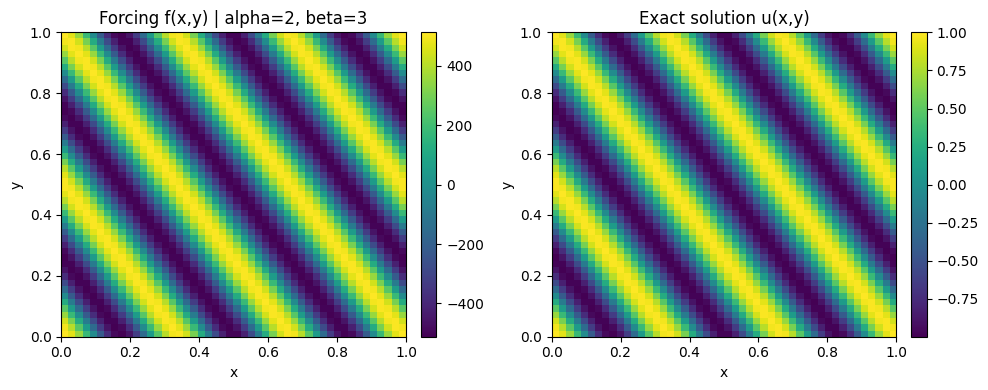

In [4]:
NX = 48
NY = 48
N_SAMPLES = 240
TRAIN_RATIO = 0.8

alpha_values = range(0, 5)
beta_values = range(0, 5)

dataset = build_dataset(
    alpha_values=alpha_values,
    beta_values=beta_values,
    n_samples=N_SAMPLES,
    nx=NX,
    ny=NY,
    seed=SEED,
)
train_set, test_set = split_dataset(dataset, train_ratio=TRAIN_RATIO, seed=SEED)

print("f:", dataset["f"].shape, "| u:", dataset["u"].shape)
print("train:", train_set["f"].shape, "| test:", test_set["f"].shape)

show_dataset_example(train_set, sample_index=0)

**Question 2.**
1. What are the shapes of `dataset["f"]`, `dataset["u"]`, `train_set["f"]`, and `train_set["u"]`?
2. Why is the channel dimension necessary even though the input is scalar-valued?

**Your answer:** *enter your answer here.*

## Part 3 — Spectral diagnostic with `fft2`

An FNO operates in Fourier space. Before using a spectral layer, we explicitly inspect
the spectrum of one example.

The core idea is:
- in physical space, we see spatial patterns;
- in frequency space, we see which modes dominate;
- an FNO learns how to transform these modes in a parameterized way.

In [ ]:
def fft_amplitude(field_2d):
    field_t = torch.as_tensor(field_2d, dtype=torch.float32)
    amp = torch.abs(torch.fft.rfft2(field_t, norm="ortho"))
    return amp.numpy()


def plot_field_and_spectrum(field_2d, title, cmap_field="viridis"):
    amp = fft_amplitude(field_2d)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(field_2d, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap=cmap_field)
    axes[0].set_title(title)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(np.log10(amp + 1e-8), origin="lower", aspect="auto", cmap="magma")
    axes[1].set_title("log10 spectrum amplitude")
    axes[1].set_xlabel("Fourier index in y")
    axes[1].set_ylabel("Fourier index in x")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


sample_id = 0
alpha0 = int(train_set["alpha"][sample_id])
beta0 = int(train_set["beta"][sample_id])

plot_field_and_spectrum(
    train_set["u"][sample_id, 0].numpy(),
    title=f"Exact solution u | alpha={alpha0}, beta={beta0}",
)
plot_field_and_spectrum(
    train_set["f"][sample_id, 0].numpy(),
    title=f"Forcing f | alpha={alpha0}, beta={beta0}",
    cmap_field="coolwarm",
)

**Question 3.**
1. In the spectrum of `u`, where are the dominant coefficients concentrated?
2. Why is it reasonable, in this lab, to retain only a limited number of Fourier modes?

**Your answer:** *enter your answer here.*

## Part 4 — A minimal spectral layer

We now implement the core of the FNO:
1. transform the field with a 2D FFT;
2. retain only a few **low modes**;
3. learn a complex linear transformation on those modes;
4. return to physical space with an inverse FFT.

We use a minimal but standard version: we treat the low positive-`x` and low
negative-`x` Fourier modes separately.

In [5]:
def compl_mul2d(a, b):
    """Complex multiplication on retained Fourier modes.

    a: (batch, in_channels, modes_x, modes_y)
    b: (in_channels, out_channels, modes_x, modes_y)
    returns: (batch, out_channels, modes_x, modes_y)
    """
    out = torch.einsum("bixy,ioxy->boxy", a, b)
    return out


class SpectralConv2d(nn.Module):
    """2D spectral convolution used inside the FNO."""

    def __init__(self, in_channels, out_channels, modes_x, modes_y):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_x = modes_x
        self.modes_y = modes_y

        scale = 1.0 / (in_channels * out_channels)
        self.weights_pos = nn.Parameter(
            scale
            * torch.randn(
                in_channels,
                out_channels,
                modes_x,
                modes_y,
                dtype=torch.cfloat,
            )
        )
        self.weights_neg = nn.Parameter(
            scale
            * torch.randn(
                in_channels,
                out_channels,
                modes_x,
                modes_y,
                dtype=torch.cfloat,
            )
        )

    def forward(self, x):
        batch_size, _, nx, ny = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            nx,
            ny // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        mx = min(self.modes_x, nx)
        my = min(self.modes_y, ny // 2 + 1)

        out_ft[:, :, :mx, :my] = compl_mul2d(
            x_ft[:, :, :mx, :my],
            self.weights_pos[:, :, :mx, :my],
        )
        out_ft[:, :, -mx:, :my] = compl_mul2d(
            x_ft[:, :, -mx:, :my],
            self.weights_neg[:, :, :mx, :my],
        )

        x = torch.fft.irfft2(out_ft, s=(nx, ny), norm="ortho")
        return x

In [10]:
class FNO2d(nn.Module):
    def __init__(self, modes_x, modes_y, width):
        super().__init__()
        self.width = width
        self.fc0 = nn.Linear(1, width)

        self.conv0 = SpectralConv2d(width, width, modes_x, modes_y)
        self.conv1 = SpectralConv2d(width, width, modes_x, modes_y)
        self.conv2 = SpectralConv2d(width, width, modes_x, modes_y)

        self.w0 = nn.Conv2d(width, width, kernel_size=1)
        self.w1 = nn.Conv2d(width, width, kernel_size=1)
        self.w2 = nn.Conv2d(width, width, kernel_size=1)

        self.fc1 = nn.Linear(width, 64)
        self.fc2 = nn.Linear(64, 1)
        self.act = nn.GELU()

    def forward(self, x):
        # TODO:
        # 1. lift the scalar field to `width` channels using fc0
        # 2. apply the three spectral blocks conv_k + w_k with GELU
        # 3. project back to one output channel
        # Hint: the pointwise Linear layers act on the last dimension.
        
        x = self.fc0(x.permute(0, 2, 3, 1))  # (batch, nx, ny, width)
    



def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [18]:
MODES_X = 8
MODES_Y = 8
WIDTH = 16

model = FNO2d(modes_x=MODES_X, modes_y=MODES_Y, width=WIDTH).to(device)
print(model)
print("Trainable parameters:", count_parameters(model))

FNO2d(
  (fc0): Linear(in_features=1, out_features=16, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (w0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (act): GELU(approximate='none')
)
Trainable parameters: 100305


**Question 4.**
1. What is the role of `fc0` before the spectral blocks?
2. Why do we add a parallel `1x1` convolution (`w0`, `w1`, `w2`)?

**Your answer:** *enter your answer here.*

## Part 5 — Training loop and metrics

We now train the FNO on the baseline dataset.

By default, the hyperparameters are chosen to remain reasonable on CPU.
If you have access to a GPU, you can increase:
- `N_SAMPLES`,
- `WIDTH`,
- `n_epochs`.

In [19]:
def make_loaders(train_set, test_set, batch_size=16):
    train_ds = TensorDataset(train_set["f"], train_set["u"])
    test_ds = TensorDataset(test_set["f"], test_set["u"])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def relative_l2_batch(pred, target, eps=1e-12):
    pred_flat = pred.reshape(pred.shape[0], -1)
    target_flat = target.reshape(target.shape[0], -1)
    numerator = torch.linalg.norm(pred_flat - target_flat, dim=1)
    denominator = torch.linalg.norm(target_flat, dim=1).clamp_min(eps)
    return numerator / denominator


@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    mse_sum = 0.0
    rel_sum = 0.0
    n_total = 0

    for f_batch, u_batch in loader:
        f_batch = f_batch.to(device)
        u_batch = u_batch.to(device)
        pred = model(f_batch)
        batch_size = f_batch.shape[0]
        mse_sum += F.mse_loss(pred, u_batch, reduction="sum").item()
        rel_sum += relative_l2_batch(pred, u_batch).sum().item()
        n_total += batch_size

    return {
        "mse": mse_sum / n_total,
        "rel_l2": rel_sum / n_total,
    }


def train_model(model, train_loader, test_loader, optimizer, n_epochs, device, print_every=10):
    history = {
        "epoch": [],
        "train_mse": [],
        "test_mse": [],
        "test_rel_l2": [],
    }

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_mse_sum = 0.0
        n_total = 0

        for f_batch, u_batch in train_loader:
            f_batch = f_batch.to(device)
            u_batch = u_batch.to(device)

            # TODO:
            # 1. reset the optimizer gradients
            # 2. predict the batch output
            # 3. compute the MSE loss
            # 4. backpropagate
            # 5. update the model parameters
            optimizer.zero_grad()
            pred = model(f_batch)
            loss = F.mse_loss(pred, u_batch)
            loss.backward()
            optimizer.step()

            batch_size = f_batch.shape[0]
            train_mse_sum += loss.item() * batch_size
            n_total += batch_size

        train_metrics = {"mse": train_mse_sum / n_total}
        test_metrics = evaluate_model(model, test_loader, device)

        history["epoch"].append(epoch)
        history["train_mse"].append(train_metrics["mse"])
        history["test_mse"].append(test_metrics["mse"])
        history["test_rel_l2"].append(test_metrics["rel_l2"])

        if epoch % print_every == 0 or epoch == 1 or epoch == n_epochs:
            print(
                f"epoch {epoch:3d} | "
                f"train mse = {train_metrics['mse']:.3e} | "
                f"test mse = {test_metrics['mse']:.3e} | "
                f"test rel L2 = {test_metrics['rel_l2']:.3e}"
            )

    return history


def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].semilogy(history["epoch"], history["train_mse"], label="train")
    axes[0].semilogy(history["epoch"], history["test_mse"], label="test")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Learning curves")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].semilogy(history["epoch"], history["test_rel_l2"], color="C2")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("relative L2")
    axes[1].set_title("Relative error on the test set")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [20]:
BATCH_SIZE = 16
N_EPOCHS = 60
LR = 1e-3

train_loader, test_loader = make_loaders(train_set, test_set, batch_size=BATCH_SIZE)
model = FNO2d(modes_x=MODES_X, modes_y=MODES_Y, width=WIDTH).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    n_epochs=N_EPOCHS,
    device=device,
    print_every=10,
)

AttributeError: 'NoneType' object has no attribute 'size'

## Part 6 — Diagnostics: exact / prediction / error

Once the model is trained, we need to inspect **how** it fails:
- exact solution map;
- prediction map;
- absolute error map;
- learning curves;
- distribution of relative errors on the test set.

In [6]:
@torch.no_grad()
def predict_dataset(model, dataset, device):
    model.eval()
    pred = model(dataset["f"].to(device)).cpu()
    return pred


def plot_prediction_triptych(model, dataset, device, sample_index=0):
    with torch.no_grad():
        pred = model(dataset["f"][sample_index:sample_index + 1].to(device)).cpu()[0, 0]

    true = dataset["u"][sample_index, 0]
    err = torch.abs(pred - true)
    alpha = int(dataset["alpha"][sample_index])
    beta = int(dataset["beta"][sample_index])

    vmin = min(true.min().item(), pred.min().item())
    vmax = max(true.max().item(), pred.max().item())

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(true.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Exact | alpha={alpha}, beta={beta}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    im1 = axes[1].imshow(pred.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title("FNO prediction")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(err.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap="inferno")
    axes[2].set_title("Absolute error")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def relative_errors_on_dataset(model, dataset, device):
    model.eval()
    pred = model(dataset["f"].to(device)).cpu()
    rel = relative_l2_batch(pred, dataset["u"])
    return rel.numpy()


plot_learning_curves(history)
plot_prediction_triptych(model, test_set, device, sample_index=0)

rel_errors = relative_errors_on_dataset(model, test_set, device)
plt.figure(figsize=(6, 4))
plt.hist(rel_errors, bins=15, edgecolor="black")
plt.xlabel("relative L2 error")
plt.ylabel("count")
plt.title("Distribution of relative errors on the test set")
plt.grid(True, alpha=0.3)
plt.show()

print("Mean test relative L2:", rel_errors.mean())

NameError: name 'plot_learning_curves' is not defined

**Question 5.**
1. Are the errors localized, or spread across the whole domain?
2. Does the network learn the low or high frequencies of this family more easily?

**Your answer:** *enter your answer here.*

## Optional bonus material

If you are working within a `1h45` session, you can stop here and move directly to the
final discussion. The next two sections are optional extensions on generalization.

## Bonus A — Out-of-distribution generalization in frequency

We now train on frequencies seen during training:
- train: `alpha, beta in {0,1,2,3}` (except `(0,0)`);
and then test on:
- test: `alpha, beta in {4,5}`.

The goal is to determine whether the FNO extrapolates correctly to more oscillatory patterns.

In [ ]:
@torch.no_grad()
def frequency_error_heatmap(model, alpha_values, beta_values, nx, ny, device):
    X, Y = make_grid(nx, ny)
    heatmap = np.full((len(alpha_values), len(beta_values)), np.nan, dtype=np.float64)

    model.eval()
    for i, alpha in enumerate(alpha_values):
        for j, beta in enumerate(beta_values):
            if alpha == 0 and beta == 0:
                continue

            f, u = build_sample(X, Y, alpha, beta)
            pred = model(f.unsqueeze(0).to(device)).cpu()
            err = relative_l2_batch(pred, u.unsqueeze(0)).item()
            heatmap[i, j] = err

    return heatmap


ood_train = build_dataset(range(0, 4), range(0, 4), n_samples=180, nx=NX, ny=NY, seed=SEED + 10)
ood_test = build_dataset(range(4, 6), range(4, 6), n_samples=60, nx=NX, ny=NY, seed=SEED + 11)

ood_train_loader, ood_test_loader = make_loaders(ood_train, ood_test, batch_size=BATCH_SIZE)
ood_model = FNO2d(modes_x=MODES_X, modes_y=MODES_Y, width=WIDTH).to(device)
ood_optimizer = torch.optim.Adam(ood_model.parameters(), lr=LR)

ood_history = train_model(
    model=ood_model,
    train_loader=ood_train_loader,
    test_loader=ood_test_loader,
    optimizer=ood_optimizer,
    n_epochs=40,
    device=device,
    print_every=10,
)

plot_learning_curves(ood_history)
plot_prediction_triptych(ood_model, ood_test, device, sample_index=0)

freq_grid = range(0, 6)
heatmap = frequency_error_heatmap(ood_model, freq_grid, freq_grid, nx=NX, ny=NY, device=device)

plt.figure(figsize=(5, 4))
plt.imshow(heatmap, origin="lower", cmap="magma")
plt.xticks(range(len(freq_grid)), list(freq_grid))
plt.yticks(range(len(freq_grid)), list(freq_grid))
plt.xlabel("beta")
plt.ylabel("alpha")
plt.title("Relative error for each (alpha, beta) pair")
plt.colorbar(label="relative L2 error")
plt.tight_layout()
plt.show()

**Question 6.**
1. Is extrapolation to unseen frequencies good, mediocre, or poor?
2. Does the degradation look progressive or abrupt?
3. What does the error heatmap tell you about the seen vs unseen region?

**Your answer:** *enter your answer here.*

## Bonus B — Changing the resolution

An important advantage of FNOs is that they can be evaluated on a grid that differs
from the one seen during training, as long as the architecture remains pointwise and
spectral.

Here, we evaluate the baseline model trained on `48 x 48` on a finer grid.

In [ ]:
@torch.no_grad()
def evaluate_on_new_resolution(model, alpha, beta, nx_new, ny_new, device):
    X_new, Y_new = make_grid(nx_new, ny_new)
    f_new, u_new = build_sample(X_new, Y_new, alpha, beta)
    pred_new = model(f_new.unsqueeze(0).to(device)).cpu()[0, 0]
    err_new = torch.abs(pred_new - u_new[0])
    rel_new = relative_l2_batch(pred_new.unsqueeze(0).unsqueeze(0), u_new.unsqueeze(0)).item()
    return u_new[0], pred_new, err_new, rel_new


alpha_res, beta_res = 2, 3
u_hi, pred_hi, err_hi, rel_hi = evaluate_on_new_resolution(
    model=model,
    alpha=alpha_res,
    beta=beta_res,
    nx_new=96,
    ny_new=96,
    device=device,
)

vmin = min(u_hi.min().item(), pred_hi.min().item())
vmax = max(u_hi.max().item(), pred_hi.max().item())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(u_hi.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=vmin, vmax=vmax)
axes[0].set_title("Exact on 96x96")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].imshow(pred_hi.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=vmin, vmax=vmax)
axes[1].set_title("FNO prediction on 96x96")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(err_hi.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap="inferno")
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Relative L2 on 96x96 for (alpha, beta)=({alpha_res}, {beta_res}): {rel_hi:.3e}")

**Question 7.**
1. Does the model remain usable when the resolution is doubled?
2. What difference do you see between generalizing in **frequency** and generalizing in **resolution**?

**Your answer:** *enter your answer here.*

## Part 9 — Reasoned comparison: FNO vs PINN

**Question 8.** Compare FNO and PINN in this lab by discussing:
1. whether a dataset `(f, u)` is needed;
2. the upfront training cost;
3. reuse on new problems;
4. dependence on the mesh and boundary conditions;
5. situations where a hybrid approach would be relevant.

**Your answer:** *enter your answer here.*

## Conclusion

If you completed this notebook, you should now be able to:
- build an operator-learning dataset `f -> u`;
- explain the role of a spectral layer;
- train a minimal FNO;
- optionally analyze its behavior under frequency and resolution generalization;
- compare its positioning with respect to PINNs.